# Task 1 — Data Loading & Exploration

In [2]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
# Upload Dataset
from google.colab import files
uploaded = files.upload()

Saving HR-Employee-Attrition.csv to HR-Employee-Attrition.csv


In [4]:
# Load Dataset
df = pd.read_csv("HR-Employee-Attrition.csv")

In [5]:
# df.head(10)
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [6]:
# Dataset Information
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
# Target Column
df["Attrition"].value_counts()
attrition_rate = (df["Attrition"]=="Yes").mean()*100
print("Attrition Rate:", round(attrition_rate,2),"%")

Attrition Rate: 16.12 %


In [18]:
# Count employees who stayed vs left
attrition_count = df["Attrition"].value_counts()

print("Employee Count:")
print(attrition_count)

# Calculate percentage
attrition_percentage = (
    df["Attrition"].value_counts(normalize=True) * 100
).round(2)

print("\nAttrition Percentage:")
print(attrition_percentage)

Employee Count:
Attrition
0    1233
1     237
Name: count, dtype: int64

Attrition Percentage:
Attrition
0    83.88
1    16.12
Name: proportion, dtype: float64


In [8]:
# Numeric vs Categorical Columns
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include="object").columns

print("Numeric Columns:",len(num_cols))
print("Categorical Columns:",len(cat_cols))

Numeric Columns: 26
Categorical Columns: 9


The attrition data is imbalanced, with significantly more employees staying than leaving the company.

# Task 2 — Data Cleaning & Preprocessing

In [9]:
# Missing Values
df.isnull().sum()
df.fillna(df.mean(numeric_only=True), inplace=True)

In [10]:
# Drop Unnecessary Columns
df.drop(
    columns=[
        "EmployeeNumber",
        "Over18",
        "StandardHours",
        "EmployeeCount"
    ],
    errors="ignore",
    inplace=True
)

In [13]:
# Split Features & Target
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [14]:
# Convert Target
y = y.map({"Yes": 1, "No": 0})

In [15]:
# One Hot Encoding
X = pd.get_dummies(X, drop_first=True)

print("Shape after One-Hot Encoding:", X.shape)
X.head()

Shape after One-Hot Encoding: (1470, 44)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


In [21]:
# Scale Numeric Features using StandardScale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


# Task 3 — Exploratory Data Analysis — EDA

In [19]:
# Attrition rate by Department
eda_df = pd.read_csv("HR-Employee-Attrition.csv")

department = pd.crosstab(eda_df["Department"], eda_df["Attrition"])

department["Attrition Rate (%)"] = (
    department["Yes"] /
    (department["Yes"] + department["No"])
) * 100

print("Attrition rate by Department")
display(department.sort_values(by="Attrition Rate (%)", ascending=False))

Attrition rate by Department


Attrition,No,Yes,Attrition Rate (%)
Department,,,
Sales,354,92,20.627803
Human Resources,51,12,19.047619
Research & Development,828,133,13.839750


Department losing the most employees: Sales (20.63%).

In [20]:
# Attrition rate by Job Role
jobrole = pd.crosstab(eda_df["JobRole"], eda_df["Attrition"])

jobrole["Attrition Rate (%)"] = (
    jobrole["Yes"] /
    (jobrole["Yes"] + jobrole["No"])
) * 100

print("Attrition rate by Job Role")
display(jobrole.sort_values(by="Attrition Rate (%)", ascending=False))

Attrition rate by Job Role


Attrition,No,Yes,Attrition Rate (%)
JobRole,,,
Sales Representative,50,33,39.759036
Laboratory Technician,197,62,23.938224
Human Resources,40,12,23.076923
Sales Executive,269,57,17.484663
Research Scientist,245,47,16.095890
Manufacturing Director,135,10,6.896552
Healthcare Representative,122,9,6.870229
Manager,97,5,4.901961
Research Director,78,2,2.500000


Job roles with highest exit rate: Sales Representative (39.76%) and Laboratory Technician (23.94%).

In [22]:
# Attrition vs Monthly Income
income = eda_df.groupby("Attrition")["MonthlyIncome"].describe()

print("Attrition vs Monthly Income")
display(income)

Attrition vs Monthly Income


,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


Lower-paid employees leave more: Yes.

In [67]:
# Attrition vs Work-Life Balance rating
wlb = pd.crosstab(eda_df["WorkLifeBalance"], eda_df["Attrition"])

wlb["Attrition Rate (%)"] = (
    wlb["Yes"] /
    (wlb["Yes"] + wlb["No"])
) * 100

print("Attrition vs Work-Life Balance rating ")
display(wlb)

Attrition vs Work-Life Balance rating 


Attrition,No,Yes,Attrition Rate (%)
WorkLifeBalance,,,
1,55,25,31.250000
2,286,58,16.860465
3,766,127,14.221725
4,126,27,17.647059


Yes, poor work-life balance is associated with much higher attrition.

In [66]:
# Attrition vs Years at Company
years = eda_df.groupby("Attrition")["YearsAtCompany"].describe()

print("Attrition vs Years at Company")
display(years)

Attrition vs Years at Company


,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,7.369019,6.096298,0.0,3.0,6.0,10.0,37.0
Yes,237.0,5.130802,5.949984,0.0,1.0,3.0,7.0,40.0


Early tenure (roughly the first 3–5 years)

In [28]:
# Overall Attrition
attrition = eda_df["Attrition"].value_counts()

print(attrition)

print("\nAttrition Percentage")

display(
    (eda_df["Attrition"].value_counts(normalize=True) * 100)
    .round(2)
    .rename("Percentage")
)

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentage


,Percentage
Attrition,
No,83.88
Yes,16.12


Business Insights
1. Sales is the highest-risk department: 20.63% of Sales employees left the company, compared with 13.84% in Research & Development.

2. Sales Representatives are the most vulnerable role: Their attrition rate is 39.76%, nearly 2.9× the company-wide attrition rate of about 16.1%.

3. Compensation matters: Employees who left had a median monthly income of ₹3,209 versus ₹5,200 for employees who stayed.

4. Poor work-life balance strongly predicts attrition: Employees with a work-life balance rating of 1 had a 31.25% attrition rate, while those with rating 3 had only 14.32%.

5. Early-career employees leave more frequently: The median tenure of employees who left was 3 years, compared with 6 years for employees who stayed, indicating that retention efforts should focus on employees in their first few years.


# Task 4 — Model Building & Comparison

In [33]:
# Features
X = df.drop("Attrition", axis=1)

# Target (already encoded)
y = df["Attrition"]

In [34]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
# Standard Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [36]:
# Logistic Regression
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=0
)

lr.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=0)

In [37]:
# Random Forest
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [38]:
# Gradient Boosting
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train,y_train)

GradientBoostingClassifier(random_state=42)

# Task 5 — Model Evaluation

In [40]:
# Model Evaluation Function
def evaluate(model,name):

    pred = model.predict(X_test)

    if hasattr(model,"predict_proba"):
        prob = model.predict_proba(X_test)[:,1]
    else:
        prob = model.decision_function(X_test)

    print(name)

    print(classification_report(y_test,pred))

    print("Precision:",precision_score(y_test,pred))

    print("Recall:",recall_score(y_test,pred))

    print("F1:",f1_score(y_test,pred))

    print("ROC AUC:",roc_auc_score(y_test,prob))

    print(confusion_matrix(y_test,pred))

# Evaluate Models
evaluate(lr,"Logistic Regression")

evaluate(rf,"Random Forest")

evaluate(gb,"Gradient Boosting")

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294

Precision: 0.34523809523809523
Recall: 0.6170212765957447
F1: 0.44274809160305345
ROC AUC: 0.7982599707123783
[[192  55]
 [ 18  29]]
Random Forest
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294

Precision: 0.4444444444444444
Recall: 0.0851063829787234
F1: 0.14285714285714285
ROC AUC: 0.7547161684899647
[[242   5]
 [ 43   4]]
Gradient Boosting
              precision    re

In [57]:
# Comparison Table
models = {
    "Logistic":lr,
    "Random Forest":rf,
    "Gradient Boosting":gb
}

results=[]

for name,model in models.items():

    pred=model.predict(X_test)

    prob=model.predict_proba(X_test)[:,1]

    results.append([
        name,
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred),
        roc_auc_score(y_test,prob)
    ])

comparison=pd.DataFrame(
    results,
    columns=[
        "Model",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
)

comparison

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic,0.345238,0.617021,0.442748,0.798260
1,Random Forest,0.444444,0.085106,0.142857,0.754716
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


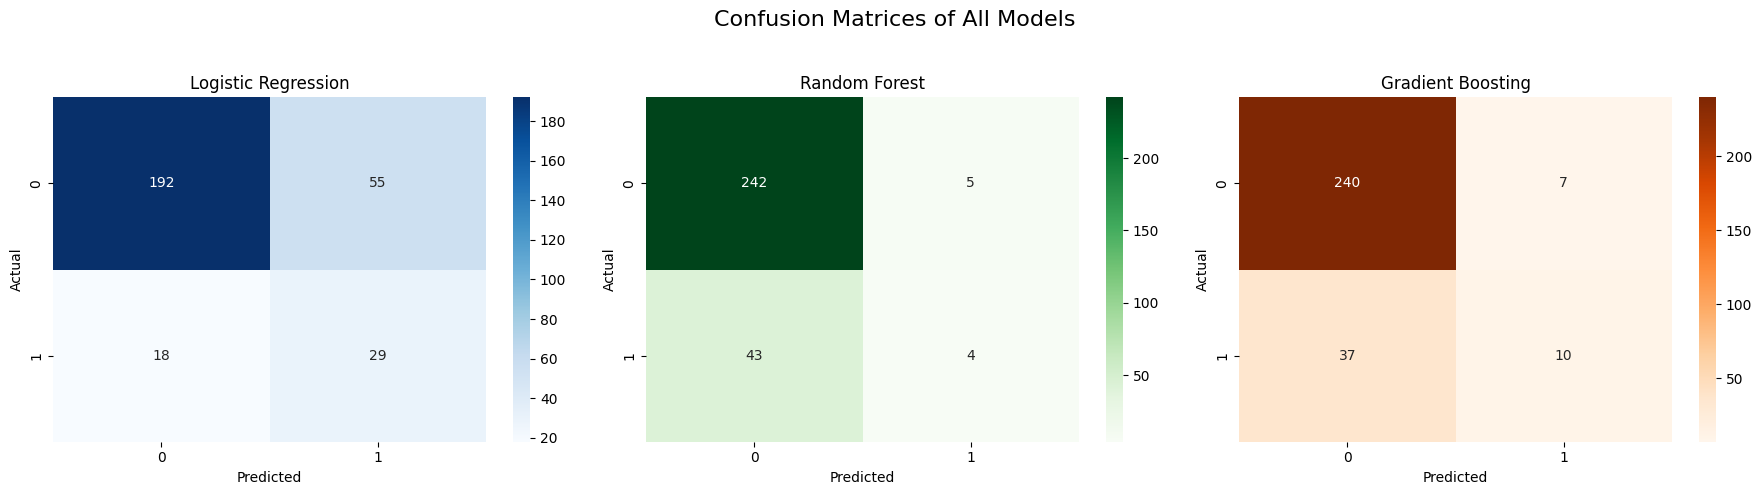

In [58]:
# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, lr.predict(X_test))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Random Forest
cm_rf = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Gradient Boosting
cm_gb = confusion_matrix(y_test, gb.predict(X_test))
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Oranges", ax=axes[2])
axes[2].set_title("Gradient Boosting")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

fig.suptitle("Confusion Matrices of All Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

Best Model: Logistic Regression

Logistic Regression performed best overall, achieving the highest Recall (0.617), F1-score (0.443), and ROC-AUC (0.798). Its confusion matrix shows that it correctly identified 29 employees who left while missing only 18, which is better than the other models. Since the primary objective of this project is to identify employees at risk of attrition, Logistic Regression is the most suitable model despite having lower precision than Gradient Boosting.

In [59]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

importance["Absolute Importance"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute Importance",
    ascending=False
)

importance.head(10)

,Feature,Coefficient,Absolute Importance
34,JobRole_Laboratory Technician,0.810172,0.810172
43,OverTime_Yes,0.771095,0.771095
23,BusinessTravel_Travel_Frequently,0.722538,0.722538
16,TotalWorkingYears,-0.660270,0.660270
7,JobLevel,0.650173,0.650173
40,JobRole_Sales Representative,0.531090,0.531090
24,BusinessTravel_Travel_Rarely,0.512780,0.512780
27,EducationField_Life Sciences,-0.512319,0.512319
21,YearsSinceLastPromotion,0.499063,0.499063
26,Department_Sales,0.470587,0.470587


# Task 6 — Visualization

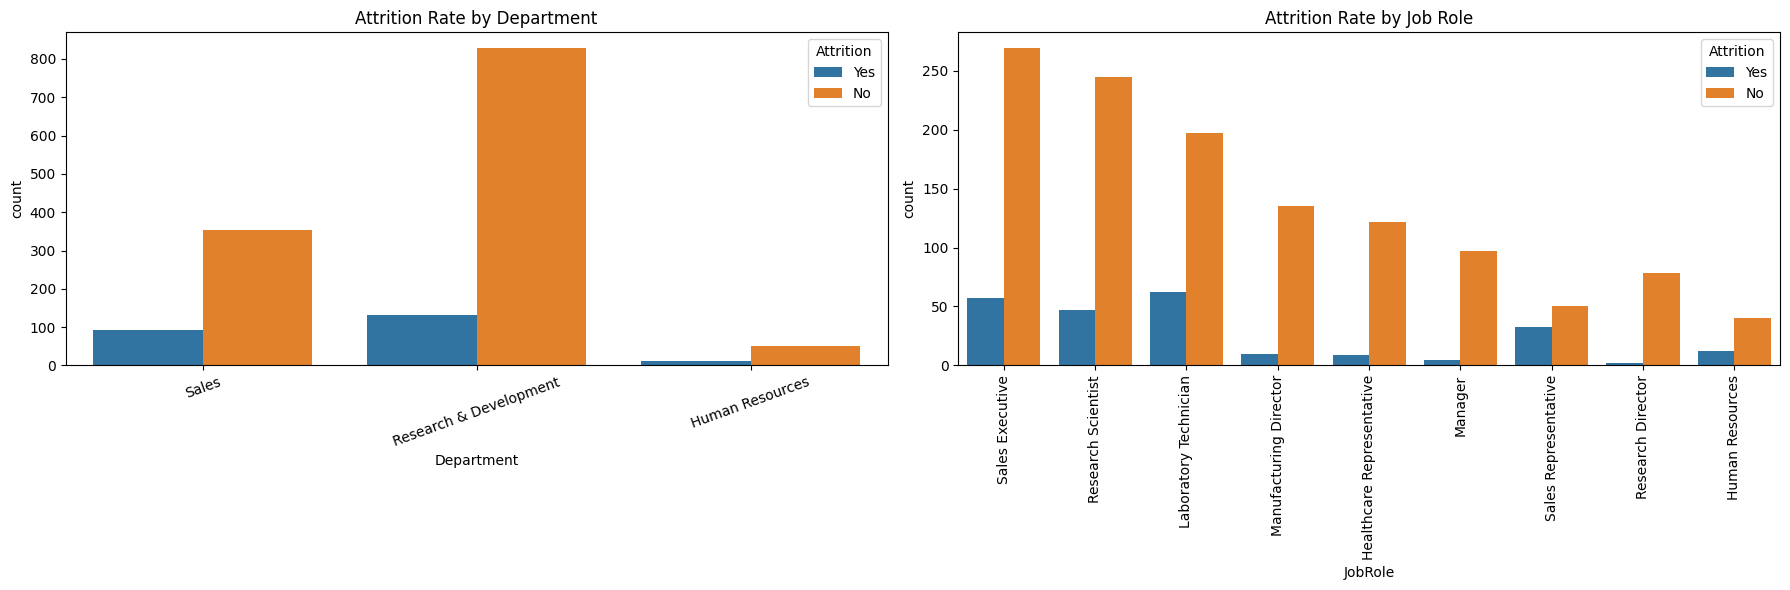

In [60]:
# Chart 1: Bar chart showing attrition rate by Department and Job Role
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Department
sns.countplot(
    data=eda_df,
    x="Department",
    hue="Attrition",
    ax=axes[0]
)
axes[0].set_title("Attrition Rate by Department")
axes[0].tick_params(axis='x', rotation=20)

# Job Role
sns.countplot(
    data=eda_df,
    x="JobRole",
    hue="Attrition",
    ax=axes[1]
)
axes[1].set_title("Attrition Rate by Job Role")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

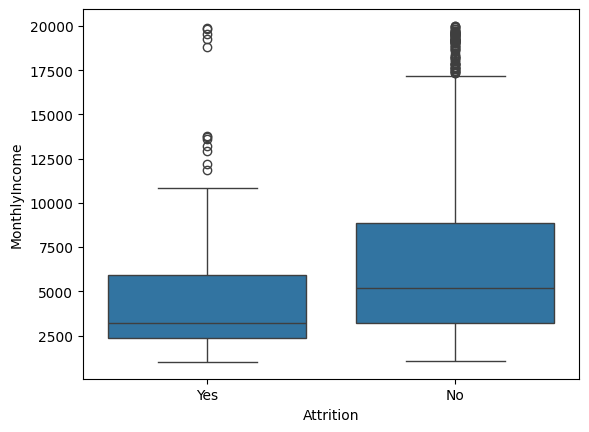

In [61]:
# Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
sns.boxplot(
    data=eda_df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.show()

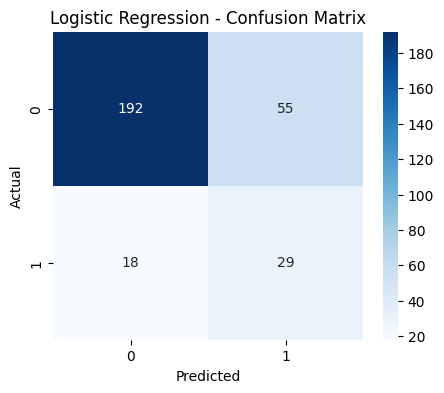

In [62]:
# Chart 3: Confusion Matrix heatmap for the best model (Logistic Regression)
cm = confusion_matrix(y_test, lr.predict(X_test))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

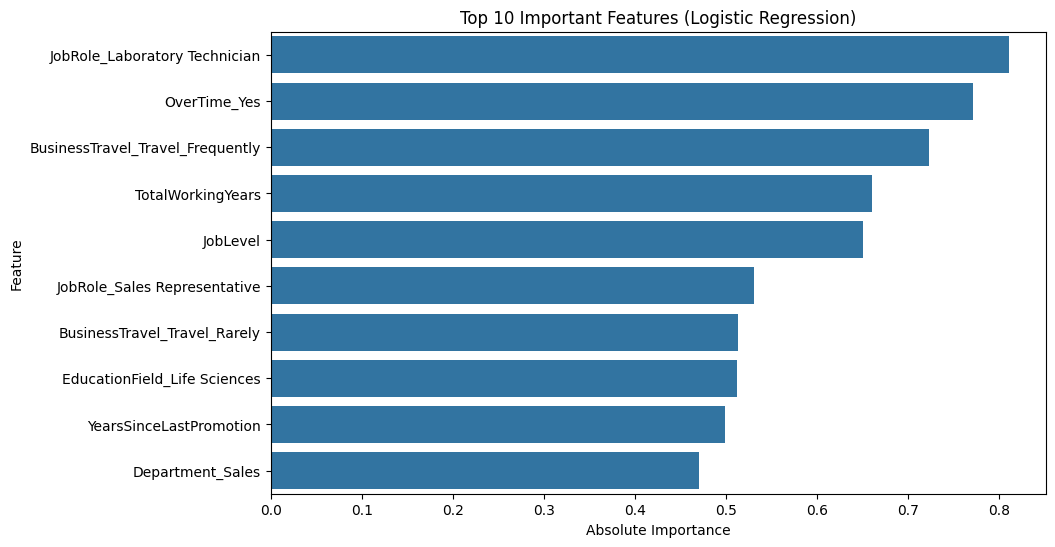

In [63]:
# Chart 4: Horizontal bar chart of Top 10 Feature Importances from the best model
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Absolute Importance",
    y="Feature"
)

plt.title("Top 10 Important Features (Logistic Regression)")
plt.show()

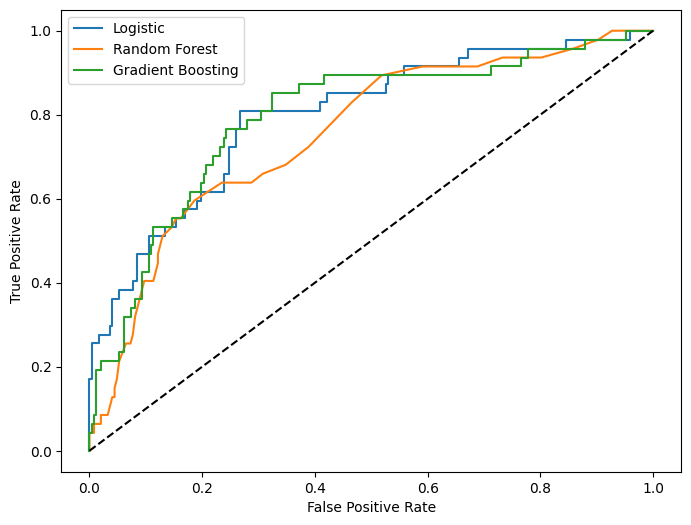

In [64]:
#  ROC Curve comparing all 3 models on one graph
plt.figure(figsize=(8,6))

for name,model in models.items():

    prob=model.predict_proba(X_test)[:,1]

    fpr,tpr,_=roc_curve(y_test,prob)

    plt.plot(fpr,tpr,label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

# Task 7 – HR Insights & Business Recommendations

### 1. Top 3 Factors Predicting Employee Attrition
- Overtime
- Frequent Business Travel
- Job Role (especially Sales Representatives and Laboratory Technicians)

### 2. Department/Job Role to Prioritize
- **Department:** Sales (Highest attrition rate: **20.63%**)
- **Job Role:** Sales Representative (Highest attrition rate: **39.76%**)

### 3. Does Salary Alone Explain Attrition?
- No. Employees with lower salaries are more likely to leave, but factors such as overtime, business travel, work-life balance, and job role have a stronger impact on attrition.

### 4. HR Recommendations
- Reduce employee overtime and improve work-life balance through flexible work policies and workload management.
- Conduct regular retention discussions and provide career growth opportunities for employees in high-risk departments and job roles, especially during their first three years.

### 5. Model Limitation
- The model is based on historical HR data and cannot capture personal reasons for leaving, such as family circumstances, better job opportunities, or organizational culture. It should be used to support HR decision-making, not replace it.